In [1]:
import random

def generate_01():
    return random.randint(0, 1)

def compute_fitness(vector):
    return sum(gen for gen in vector)

def create_vector():
    return [generate_01() for _ in range(n)]

def exchange(vector1, vector2, n, rate=0.9):
    vector1_new = vector1.copy()
    vector2_new = vector2.copy()
    
    for i in range(n):
        if random.random() < rate:
            vector1_new[i] = vector2[i]
            vector2_new[i] = vector1[i]            
    
    return vector1_new, vector2_new

In [2]:
n = 10                 # size of individual (chromosome)
m = 8                  # size of population
n_generations = 30     # number of generations

fitnesses = []

# loops 
for i in range(n_generations):
    # 1. create vectors
    vectors = [create_vector() for _ in range(m)]

    # 2. sort vectors
    # debug
    sorted_vectors = sorted(vectors, key=compute_fitness)
    if i%1 == 0:
        fitnesses.append(compute_fitness(sorted_vectors[m-1]))
        print("BEST:", compute_fitness(sorted_vectors[m-1]))      
    
    # exchange
    new_population = []
    while len(new_population) < m:
        # get two vectors
        index1 = random.randint(0, m-1)    
        index2 = random.randint(0, m-1)    
        
        while index2 == index1:
            index2 = random.randint(0, m-1)  
            
        vector1 = vectors[index1]
        vector2 = vectors[index2]
        
        # exchange
        vector1, vector2 = exchange(vector1, vector2, n)
        
        # save these two vectors
        new_population.append(vector1)
        new_population.append(vector2) 
        
    # update
    population = new_population

BEST: 7
BEST: 9
BEST: 7
BEST: 6
BEST: 6
BEST: 7
BEST: 9
BEST: 8
BEST: 7
BEST: 8
BEST: 6
BEST: 9
BEST: 8
BEST: 8
BEST: 8
BEST: 8
BEST: 7
BEST: 7
BEST: 9
BEST: 5
BEST: 7
BEST: 8
BEST: 7
BEST: 7
BEST: 7
BEST: 7
BEST: 8
BEST: 7
BEST: 6
BEST: 6


In [3]:
sorted_vectors = sorted(vectors, key=compute_fitness)
vector_best = sorted_vectors[-1]
print(vector_best)

[1, 1, 0, 1, 0, 0, 1, 0, 1, 1]


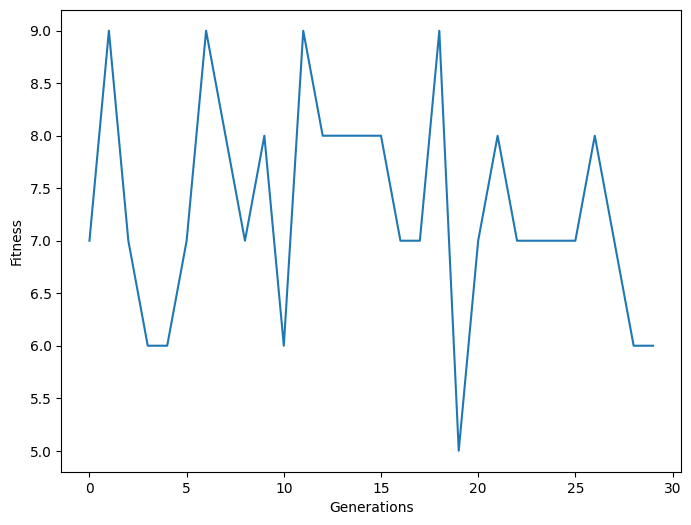

In [4]:
import matplotlib.pyplot as plt
#%matplotlib qt

fig, ax = plt.subplots(figsize=(8, 6))
#ax.set_ylim((12, 21))

plt.plot(fitnesses)
plt.xlabel('Generations')
plt.ylabel('Fitness')
plt.show()